In [110]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
import operator

In [111]:
model = ChatGroq(
    api_key=os.environ.get("GROQ_API_KEY"),
    model="llama-3.1-8b-instant")

In [112]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="The evaluation of the output text.")
    score: int = Field(description="The score assigned to the output text out of  10.")

In [113]:
structured_model = model.with_structured_output(EvaluationSchema)

In [114]:
essay = """Artificial Intelligence is playing an important role 
 in healthcare by helping doctors, nurses, researchers,
 and patients. AI means using computer systems that can 
 learn from data and make intelligent decisions. In hospitals,
 AI can help doctors diagnose diseases more quickly and accurately.
 For example, AI systems can study X-rays, MRI scans, and blood 
 reports to detect problems such as cancer, heart disease, or 
 infections.

AI is also useful in treatment planning. It can analyze a patient’s
medical history and suggest suitable treatment options. This helps
doctors make better decisions and reduces the chances of mistakes.
In addition, AI-powered chatbots and virtual assistants can 
guide patients, remind them to take medicines, and answer basic 
health questions.

Another important role of AI is in medical research. It can process 
large amounts of data and help scientists discover new medicines
faster. AI can also predict disease outbreaks and support public 
health planning.

However, AI cannot replace doctors completely. Human care, empathy
,and experience are still very important in healthcare. AI should 
be used as a supporting tool, not as a replacement. Overall, AI has
the power to make healthcare faster, smarter, and more accessible 
for everyone.
"""

In [115]:
prompt = """
Evaluate the essay.

Return your answer strictly in this format:
{
  "feedback": "your feedback here",
  "score": integer score from 1 to 10
}

Essay:
{essay}
"""

In [116]:
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay is well-structured and demonstrates a clear understanding of the topic. However, there are some minor grammatical errors and the writing could be more engaging.', score=7)

In [117]:
class EssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str

    overall_feedback: str

    # reducer function used to prevent overwriting
    # individual scores are merged
    individual_scores: Annotated[list[int], operator.add]

    average_score: float


In [118]:
graph = StateGraph(EssayState)

In [119]:
def evaluate_language(state: EssayState) -> EssayState:
    prompt = f"Please evaluate the language of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structured_model.invoke(prompt)
  
    return {'language_feedback': result.feedback, 'individual_scores': [result.score]}



def evaluate_analysis(state: EssayState) -> EssayState:
    prompt = f"Please evaluate the depth of analysis of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structured_model.invoke(prompt)
  
    return {'analysis_feedback': result.feedback, 'individual_scores': [result.score]}


def evaluate_clarity(state: EssayState) -> EssayState:
    prompt = f"Please evaluate the clarity of thought of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structured_model.invoke(prompt)
  
    return {'clarity_feedback': result.feedback, 'individual_scores': [result.score]}

def final_evaluation(state: EssayState):
    scores = state["individual_scores"]
    average = sum(scores) / len(scores)

    overall = f"""
Language Feedback:
{state["language_feedback"]}

Analysis Feedback:
{state["analysis_feedback"]}

Clarity Feedback:
{state["clarity_feedback"]}

Average Score: {average:.2f}/10
"""

    return {
        "overall_feedback": overall,
        "average_score": average
    }

In [120]:
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_feedback', final_feedback)


In [121]:
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'final_feedback')
graph.add_edge('evaluate_analysis', 'final_feedback')
graph.add_edge('evaluate_clarity', 'final_feedback')

graph.add_edge('final_feedback', END)

In [122]:
workflow = graph.compile()

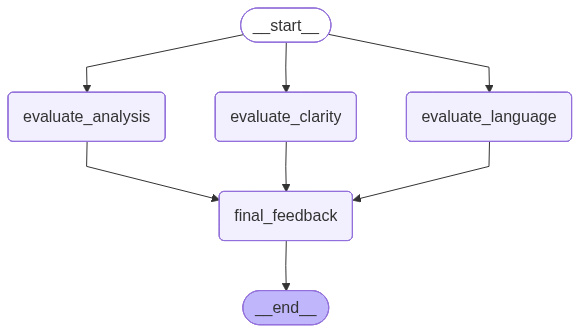

In [123]:
workflow

In [124]:
initial_state = {
    'essay': essay
}

workflow.invoke(initial_state)

{'essay': 'Artificial Intelligence is playing an important role \n in healthcare by helping doctors, nurses, researchers,\n and patients. AI means using computer systems that can \n learn from data and make intelligent decisions. In hospitals,\n AI can help doctors diagnose diseases more quickly and accurately.\n For example, AI systems can study X-rays, MRI scans, and blood \n reports to detect problems such as cancer, heart disease, or \n infections.\n\nAI is also useful in treatment planning. It can analyze a patient’s\nmedical history and suggest suitable treatment options. This helps\ndoctors make better decisions and reduces the chances of mistakes.\nIn addition, AI-powered chatbots and virtual assistants can \nguide patients, remind them to take medicines, and answer basic \nhealth questions.\n\nAnother important role of AI is in medical research. It can process \nlarge amounts of data and help scientists discover new medicines\nfaster. AI can also predict disease outbreaks and 